# Resultados 2021 por proceso

Este notebook calcula los indices por proceso para 2021 a partir de los archivos `embeddings_2021_<start>_<end>.csv` ya generados.

Indices calculados:
- `IC_M1_rf`, `IC_M1_lr`: media de probabilidades por proceso.
- `IC_M2_rf`, `IC_M2_lr`: Noisy-OR por proceso.
- `IC_M3`: soft vote ponderado con los pesos RF/LR usados en el notebook parcial.
- `IC_M4`: Noisy-OR del soft vote ponderado.
- `IC_M5_density`: proporcion de preguntas clasificadas como acusatorias usando la version binaria de RF/LR y un voto ponderado binario normalizado.


In [1]:
#imports

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

KeyboardInterrupt: 

In [5]:
W_LR = 0.5478240336268073
W_RF = 0.3998231918002441
ACTIVE_WEIGHT_SUM = W_LR + W_RF
W_LR_ACTIVE = W_LR / ACTIVE_WEIGHT_SUM
W_RF_ACTIVE = W_RF / ACTIVE_WEIGHT_SUM

EMBEDDING_FILE_RE = re.compile(r"^embeddings_2021_(\d+)_(\d+)\.csv$")


@dataclass(frozen=True)
class Paths:
    codes_dir: Path
    output_dir: Path
    prepared_data_path: Path
    train_rf_path: Path
    train_lr_path: Path
    indices_output_path: Path


def resolve_codes_dir() -> Path:
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd / "Codes")
    candidates.extend(cwd.parents)
    candidates.extend(parent / "Codes" for parent in cwd.parents)

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if not candidate.exists() or not candidate.is_dir():
            continue
        if (candidate / "output" / "2021").exists() and (candidate / "Archivos_Random_Forest").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo ubicar la carpeta Codes. Ejecuta el notebook desde el proyecto o ajusta las rutas manualmente."
    )


def default_paths() -> Paths:
    codes_dir = resolve_codes_dir()
    output_dir = codes_dir / "output" / "2021"
    return Paths(
        codes_dir=codes_dir,
        output_dir=output_dir,
        prepared_data_path=output_dir / "preguntas_2021_prepared.csv",
        train_rf_path=codes_dir
        / "Archivos_Random_Forest"
        / "train_embeddings_balanced_total_sentence_prompt_GPT4o_mini_text-embedding-3-large.csv",
        train_lr_path=codes_dir
        / "Archivos_Logistic_Regression"
        / "train_embeddings_balanced_total_sinonimos_text-embedding-3-large.csv",
        indices_output_path=output_dir / "indices_per_process.csv",
    )


def parse_embedding_ranges(output_dir: Path) -> list[tuple[int, int, Path]]:
    files: list[tuple[int, int, Path]] = []
    for path in output_dir.glob("embeddings_2021_*_*.csv"):
        match = EMBEDDING_FILE_RE.match(path.name)
        if not match:
            continue
        start_idx = int(match.group(1))
        end_idx = int(match.group(2))
        files.append((start_idx, end_idx, path))
    return sorted(files, key=lambda item: item[0])


def validate_ranges(
    embedding_ranges: list[tuple[int, int, Path]], total_rows: int
) -> None:
    if not embedding_ranges:
        raise FileNotFoundError("No se encontraron archivos embeddings_2021_<start>_<end>.csv.")

    expected_start = 0
    for start_idx, end_idx, path in embedding_ranges:
        if start_idx != expected_start:
            raise ValueError(
                f"Falta cobertura de embeddings. Se esperaba inicio {expected_start} "
                f"pero el archivo {path.name} empieza en {start_idx}."
            )
        if end_idx <= start_idx:
            raise ValueError(f"Rango invalido en {path.name}.")
        expected_start = end_idx

    if expected_start != total_rows:
        raise ValueError(
            f"Los embeddings cubren hasta la fila {expected_start}, pero el dataset preparado "
            f"tiene {total_rows} filas."
        )


def load_training_matrix(train_path: Path) -> tuple[np.ndarray, np.ndarray, list[str]]:
    train_df = pd.read_csv(train_path, dtype=np.float32)
    if "label" not in train_df.columns:
        raise ValueError(f"El archivo {train_path.name} no contiene la columna label.")

    feature_cols = [col for col in train_df.columns if col != "label"]
    x_train = train_df[feature_cols].to_numpy(dtype=np.float32, copy=False)
    y_train = train_df["label"].to_numpy(dtype=np.int8, copy=False)
    return x_train, y_train, feature_cols


def train_models(paths: Paths) -> tuple[RandomForestClassifier, list[str], LogisticRegression, list[str]]:
    print("Entrenando Random Forest...")
    x_train_rf, y_train_rf, feature_cols_rf = load_training_matrix(paths.train_rf_path)
    model_rf = RandomForestClassifier(
        max_depth=None,
        min_samples_leaf=1,
        n_estimators=200,
        random_state=42,
        n_jobs=1,
    )
    model_rf.fit(x_train_rf, y_train_rf)
    del x_train_rf, y_train_rf

    print("Entrenando Logistic Regression...")
    x_train_lr, y_train_lr, feature_cols_lr = load_training_matrix(paths.train_lr_path)
    model_lr = LogisticRegression(
        C=100,
        penalty="l2",
        solver="saga",
        max_iter=1000,
        random_state=42,
    )
    model_lr.fit(x_train_lr, y_train_lr)
    del x_train_lr, y_train_lr

    return model_rf, feature_cols_rf, model_lr, feature_cols_lr


def build_chunk_aggregates(
    contract_ids: pd.Series,
    prob_rf: np.ndarray,
    prob_lr: np.ndarray,
    pred_rf: np.ndarray,
    pred_lr: np.ndarray,
) -> pd.DataFrame:
    soft_score = W_LR * prob_lr + W_RF * prob_rf
    binary_vote = (
        W_LR_ACTIVE * pred_lr.astype(np.float32) + W_RF_ACTIVE * pred_rf.astype(np.float32)
    ) >= 0.5

    chunk_df = pd.DataFrame(
        {
            "contract_id": contract_ids.to_numpy(copy=False),
            "prob_rf": prob_rf,
            "prob_lr": prob_lr,
            "one_minus_prob_rf": 1.0 - np.clip(prob_rf, 0.0, 1.0),
            "one_minus_prob_lr": 1.0 - np.clip(prob_lr, 0.0, 1.0),
            "soft_score": soft_score,
            "one_minus_soft": 1.0 - np.clip(soft_score, 0.0, 1.0),
            "binary_vote": binary_vote.astype(np.int8),
        }
    )

    return (
        chunk_df.groupby("contract_id", sort=False, as_index=False)
        .agg(
            n_preguntas=("contract_id", "size"),
            sum_prob_rf=("prob_rf", "sum"),
            sum_prob_lr=("prob_lr", "sum"),
            prod_one_minus_rf=("one_minus_prob_rf", "prod"),
            prod_one_minus_lr=("one_minus_prob_lr", "prod"),
            sum_soft=("soft_score", "sum"),
            prod_one_minus_soft=("one_minus_soft", "prod"),
            sum_binary_vote=("binary_vote", "sum"),
        )
    )


def accumulate_process_stats(
    accumulator: dict[str, dict[str, float]],
    chunk_agg: pd.DataFrame,
) -> None:
    for row in chunk_agg.itertuples(index=False):
        contract_id = str(row.contract_id)
        current = accumulator.setdefault(
            contract_id,
            {
                "n_preguntas": 0,
                "sum_prob_rf": 0.0,
                "sum_prob_lr": 0.0,
                "prod_one_minus_rf": 1.0,
                "prod_one_minus_lr": 1.0,
                "sum_soft": 0.0,
                "prod_one_minus_soft": 1.0,
                "sum_binary_vote": 0.0,
            },
        )
        current["n_preguntas"] += int(row.n_preguntas)
        current["sum_prob_rf"] += float(row.sum_prob_rf)
        current["sum_prob_lr"] += float(row.sum_prob_lr)
        current["prod_one_minus_rf"] *= float(row.prod_one_minus_rf)
        current["prod_one_minus_lr"] *= float(row.prod_one_minus_lr)
        current["sum_soft"] += float(row.sum_soft)
        current["prod_one_minus_soft"] *= float(row.prod_one_minus_soft)
        current["sum_binary_vote"] += float(row.sum_binary_vote)


def finalize_indices(accumulator: dict[str, dict[str, float]]) -> pd.DataFrame:
    rows: list[dict[str, float | str | int]] = []
    for contract_id in sorted(accumulator):
        stats = accumulator[contract_id]
        n_preguntas = int(stats["n_preguntas"])
        rows.append(
            {
                "contract_id": contract_id,
                "n_preguntas": n_preguntas,
                "IC_M1_rf": stats["sum_prob_rf"] / n_preguntas,
                "IC_M1_lr": stats["sum_prob_lr"] / n_preguntas,
                "IC_M2_rf": 1.0 - stats["prod_one_minus_rf"],
                "IC_M2_lr": 1.0 - stats["prod_one_minus_lr"],
                "IC_M3": stats["sum_soft"] / n_preguntas,
                "IC_M4": 1.0 - stats["prod_one_minus_soft"],
                "IC_M5_density": stats["sum_binary_vote"] / n_preguntas,
            }
        )
    return pd.DataFrame(rows)


def run_pipeline() -> pd.DataFrame:
    paths = default_paths()
    print(f"codes_dir: {paths.codes_dir}")
    print(f"output_dir: {paths.output_dir}")
    prepared_df = pd.read_csv(paths.prepared_data_path, usecols=["contract_id"])
    embedding_ranges = parse_embedding_ranges(paths.output_dir)
    validate_ranges(embedding_ranges, len(prepared_df))

    model_rf, feature_cols_rf, model_lr, feature_cols_lr = train_models(paths)
    accumulator: dict[str, dict[str, float]] = {}

    for start_idx, end_idx, embedding_path in embedding_ranges:
        print(f"Procesando {embedding_path.name} [{start_idx}, {end_idx})...")
        emb_df = pd.read_csv(embedding_path, dtype=np.float32)
        expected_rows = end_idx - start_idx
        if len(emb_df) != expected_rows:
            raise ValueError(
                f"{embedding_path.name} tiene {len(emb_df)} filas y se esperaban {expected_rows}."
            )

        meta_chunk = prepared_df.iloc[start_idx:end_idx].reset_index(drop=True)
        if len(meta_chunk) != len(emb_df):
            raise ValueError(
                f"Desalineacion entre metadata y embeddings para {embedding_path.name}."
            )

        missing_rf = [col for col in feature_cols_rf if col not in emb_df.columns]
        if missing_rf:
            raise ValueError(
                f"Faltan columnas RF en {embedding_path.name}: {missing_rf[:5]}"
            )
        missing_lr = [col for col in feature_cols_lr if col not in emb_df.columns]
        if missing_lr:
            raise ValueError(
                f"Faltan columnas LR en {embedding_path.name}: {missing_lr[:5]}"
            )

        x_rf = emb_df[feature_cols_rf].to_numpy(dtype=np.float32, copy=False)
        x_lr = emb_df[feature_cols_lr].to_numpy(dtype=np.float32, copy=False)

        prob_rf = model_rf.predict_proba(x_rf)[:, 1].astype(np.float32, copy=False)
        prob_lr = model_lr.predict_proba(x_lr)[:, 1].astype(np.float32, copy=False)
        pred_rf = model_rf.predict(x_rf).astype(np.int8, copy=False)
        pred_lr = model_lr.predict(x_lr).astype(np.int8, copy=False)

        chunk_agg = build_chunk_aggregates(
            contract_ids=meta_chunk["contract_id"],
            prob_rf=prob_rf,
            prob_lr=prob_lr,
            pred_rf=pred_rf,
            pred_lr=pred_lr,
        )
        accumulate_process_stats(accumulator, chunk_agg)

        del emb_df, meta_chunk, x_rf, x_lr, prob_rf, prob_lr, pred_rf, pred_lr, chunk_agg

    indices_df = finalize_indices(accumulator)
    paths.indices_output_path.parent.mkdir(parents=True, exist_ok=True)
    indices_df.to_csv(paths.indices_output_path, index=False, encoding="utf-8")

    print(f"Procesos con indices: {len(indices_df):,}")
    print(f"Archivo generado: {paths.indices_output_path}")
    return indices_df


In [6]:
# Ejecutar el pipeline y mostrar los primeros resultados 
# Se ejecuta una sola vez, ya que el proceso es costoso. El resultado se guarda en output/2021/indices_per_process.csv

indices_df = run_pipeline()
indices_df.head(10)


codes_dir: D:\Noveno Semestre\Tesis Informal\Codes
output_dir: D:\Noveno Semestre\Tesis Informal\Codes\output\2021
Entrenando Random Forest...


KeyboardInterrupt: 

## Indices normalizados

Para hacer comparables los indices entre si, esta seccion calcula versiones normalizadas con z-score y las exporta a `indices_per_process_normalized.csv`.


In [11]:
INDEX_COLUMNS = [
    "IC_M1_rf",
    "IC_M1_lr",
    "IC_M2_rf",
    "IC_M2_lr",
    "IC_M3",
    "IC_M4",
    "IC_M5_density",
]

def zscore_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        mean = normalized_df[col].mean()
        std = normalized_df[col].std(ddof=0)
        out_col = f"{col}_zscore"
        if std == 0 or pd.isna(std):
            normalized_df[out_col] = 0.0
        else:
            normalized_df[out_col] = (normalized_df[col] - mean) / std
    return normalized_df

normalized_indices_df = zscore_normalize_indices(indices_df, INDEX_COLUMNS)
normalized_output_path = default_paths().output_dir / "indices_per_process_normalized.csv"
normalized_indices_df.to_csv(normalized_output_path, index=False)

print(f"Archivo generado: {normalized_output_path}")
normalized_indices_df.head(10)


Archivo generado: D:\Noveno Semestre\Tesis Informal\Codes\output\2021\indices_per_process_normalized.csv


,contract_id,n_preguntas,IC_M1_rf,IC_M1_lr,IC_M2_rf,IC_M2_lr,IC_M3,IC_M4,IC_M5_density,IC_M1_rf_zscore,IC_M1_lr_zscore,IC_M2_rf_zscore,IC_M2_lr_zscore,IC_M3_zscore,IC_M4_zscore,IC_M5_density_zscore
0,1608622,9,0.256667,0.028370,0.936814,0.252460,0.118163,0.685112,0.0,0.387719,-0.056041,0.990670,0.332909,0.131557,0.821393,-0.264623
1,1608717,4,0.221250,0.005547,0.639800,0.022151,0.091500,0.320846,0.0,0.010147,-0.277652,0.008990,-0.417156,-0.176708,-0.371167,-0.264623
2,1608968,3,0.078333,0.000368,0.220720,0.001105,0.031521,0.092213,0.0,-1.513469,-0.327932,-1.376137,-0.485701,-0.870132,-1.119683,-0.264623
3,1609087,2,0.160000,0.000001,0.294625,0.000002,0.063972,0.123888,0.0,-0.642832,-0.331498,-1.131869,-0.489292,-0.494958,-1.015982,-0.264623
4,1609116,13,0.206154,0.001334,0.956400,0.017274,0.083156,0.681338,0.0,-0.150791,-0.318554,1.055405,-0.433041,-0.273170,0.809035,-0.264623
5,1609119,2,0.345000,0.001760,0.578200,0.003521,0.138903,0.259733,0.0,1.329429,-0.314416,-0.194607,-0.477833,0.371340,-0.571244,-0.264623
6,1609206,1,0.200000,0.000003,0.200000,0.000003,0.079966,0.079966,0.0,-0.216397,-0.331484,-1.444620,-0.489290,-0.310050,-1.159777,-0.264623
7,1609217,19,0.190789,0.000491,0.983271,0.009290,0.076551,0.781586,0.0,-0.314589,-0.326745,1.144218,-0.459043,-0.349534,1.137237,-0.264623
8,1609219,2,0.175000,0.000017,0.319400,0.000035,0.069979,0.135064,0.0,-0.482918,-0.331340,-1.049984,-0.489185,-0.425517,-0.979393,-0.264623
9,1609235,2,0.642500,0.522960,0.917350,0.989146,0.543377,0.907087,0.5,4.501037,4.746312,0.926339,2.732133,5.047557,1.548109,4.177249


### Normalizacion por rango percentil

Mapea cada valor de indice a su posicion percentil dentro del dataset (0–100). No asume ninguna distribucion subyacente y es completamente robusto a outliers. Un valor de 99 significa que ese proceso supera al 99 % de los demas en ese indice.

In [3]:
def percentile_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        normalized_df[f"{col}_pct"] = normalized_df[col].rank(pct=True) * 100
    return normalized_df

percentile_indices_df = percentile_normalize_indices(indices_df, INDEX_COLUMNS)
percentile_output_path = default_paths().output_dir / "indices_per_process_normalized_percentile.csv"
percentile_indices_df.to_csv(percentile_output_path, index=False)

print(f"Archivo generado: {percentile_output_path}")
percentile_indices_df.head(10)

NameError: name 'indices_df' is not defined

### Normalizacion por z-score robusto (mediana + IQR)

Sustituye la media y la desviacion estandar por la mediana y el rango intercuartilico (IQR). Al no verse afectado por valores extremos, es mas adecuado para detectar procesos anomalos: los outliers conservan z-scores altos sin comprimir el resto de la distribucion.

In [ ]:
def robust_zscore_normalize_indices(df: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    normalized_df = df.copy()
    for col in index_columns:
        median = normalized_df[col].median()
        iqr = normalized_df[col].quantile(0.75) - normalized_df[col].quantile(0.25)
        out_col = f"{col}_robustZ"
        if iqr == 0 or pd.isna(iqr):
            normalized_df[out_col] = 0.0
        else:
            normalized_df[out_col] = (normalized_df[col] - median) / iqr
    return normalized_df

robustz_indices_df = robust_zscore_normalize_indices(indices_df, INDEX_COLUMNS)
robustz_output_path = default_paths().output_dir / "indices_per_process_normalized_robustZ.csv"
robustz_indices_df.to_csv(robustz_output_path, index=False)

print(f"Archivo generado: {robustz_output_path}")
robustz_indices_df.head(10)

## Analisis semanal de procesos

Esta seccion compara procesos entre dos semanas para todos los indices. Por defecto usa las primeras dos semanas disponibles segun la primera fecha de pregunta de cada proceso. Si quieres otras semanas, cambia `SELECTED_WEEKS` manualmente.


In [12]:
import math
import matplotlib.pyplot as plt

RAW_INDEX_COLUMNS = [
    "IC_M1_rf",
    "IC_M1_lr",
    "IC_M2_rf",
    "IC_M2_lr",
    "IC_M3",
    "IC_M4",
    "IC_M5_density",
]
ZSCORE_INDEX_COLUMNS = [f"{col}_zscore" for col in RAW_INDEX_COLUMNS]
TOP_K_VALUES = [1, 3, 5]
SELECTED_WEEKS = None  # Ejemplo: ["2021-01-04", "2021-01-11"]


def build_process_week_frame(paths: Paths) -> pd.DataFrame:
    process_dates = pd.read_csv(
        paths.prepared_data_path,
        usecols=["contract_id", "fecha_publicacion"],
        parse_dates=["fecha_publicacion"],
    )
    process_dates["contract_id"] = process_dates["contract_id"].astype(str)
    weekly_df = (
        process_dates.groupby("contract_id", as_index=False)
        .agg(
            first_question_date=("fecha_publicacion", "min"),
            last_question_date=("fecha_publicacion", "max"),
            process_question_count=("fecha_publicacion", "size"),
        )
        .sort_values(["first_question_date", "contract_id"])
        .reset_index(drop=True)
    )
    weekly_df["week_start"] = weekly_df["first_question_date"].dt.to_period("W-SUN").dt.start_time
    weekly_df["week_label"] = weekly_df["week_start"].dt.strftime("%Y-%m-%d")
    return weekly_df


def pick_two_weeks(weekly_df: pd.DataFrame, selected_weeks: list[str] | None) -> list[str]:
    available_weeks = sorted(weekly_df["week_label"].dropna().unique().tolist())
    if selected_weeks is None:
        return available_weeks[:2]
    missing = [week for week in selected_weeks if week not in available_weeks]
    if missing:
        raise ValueError(f"Semanas no disponibles: {missing}")
    return selected_weeks[:2]


def make_axis_grid(total_plots: int, ncols: int = 2, figsize_scale: float = 4.5):
    nrows = math.ceil(total_plots / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, figsize_scale * nrows), squeeze=False)
    flat_axes = axes.flatten()
    for ax in flat_axes[total_plots:]:
        ax.axis("off")
    return fig, flat_axes


def plot_weekly_boxplots(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    for ax, col in zip(axes, zscore_cols):
        data = [df.loc[df["week_label"] == week, col].dropna().to_numpy() for week in selected_weeks]
        ax.boxplot(data, labels=selected_weeks, patch_artist=True)
        ax.set_title(f"Boxplot {col}")
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
        ax.tick_params(axis="x", rotation=20)
    fig.suptitle("Distribucion semanal por indice normalizado", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_weekly_violins(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    for ax, col in zip(axes, zscore_cols):
        data = [df.loc[df["week_label"] == week, col].dropna().to_numpy() for week in selected_weeks]
        parts = ax.violinplot(data, positions=np.arange(1, len(selected_weeks) + 1), showmeans=True, showextrema=True)
        for body in parts["bodies"]:
            body.set_alpha(0.5)
        ax.set_title(f"Violin {col}")
        ax.set_xticks(np.arange(1, len(selected_weeks) + 1))
        ax.set_xticklabels(selected_weeks, rotation=20)
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
    fig.suptitle("Forma de distribucion semanal por indice normalizado", fontsize=14)
    fig.tight_layout()
    plt.show()


def compute_topk_summary(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str], top_k_values: list[int]) -> pd.DataFrame:
    rows = []
    for week in selected_weeks:
        week_df = df[df["week_label"] == week]
        for col in zscore_cols:
            row = {"week_label": week, "index_name": col, "max": week_df[col].max()}
            for k in top_k_values:
                row[f"top_{k}_mean"] = week_df.nlargest(min(k, len(week_df)), col)[col].mean()
            rows.append(row)
    return pd.DataFrame(rows)


def plot_topk_lines(summary_df: pd.DataFrame, zscore_cols: list[str]) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.0)
    metric_cols = ["max"] + [f"top_{k}_mean" for k in TOP_K_VALUES]
    for ax, col in zip(axes, zscore_cols):
        idx_df = summary_df[summary_df["index_name"] == col].sort_values("week_label")
        for metric in metric_cols:
            ax.plot(idx_df["week_label"], idx_df[metric], marker="o", label=metric)
        ax.set_title(f"Top-k {col}")
        ax.set_xlabel("Semana")
        ax.set_ylabel("Z-score")
        ax.tick_params(axis="x", rotation=20)
        ax.legend(fontsize=8)
    fig.suptitle("Procesos mas altos por semana", fontsize=14)
    fig.tight_layout()
    plt.show()


def compute_concentration_summary(df: pd.DataFrame, raw_cols: list[str], selected_weeks: list[str], top_k_values: list[int]) -> pd.DataFrame:
    rows = []
    for week in selected_weeks:
        week_df = df[df["week_label"] == week]
        for col in raw_cols:
            total = week_df[col].sum()
            row = {"week_label": week, "index_name": col, "total": total}
            for k in top_k_values:
                top_sum = week_df.nlargest(min(k, len(week_df)), col)[col].sum()
                row[f"top_{k}_share"] = 0.0 if total == 0 else top_sum / total
            rows.append(row)
    return pd.DataFrame(rows)


def plot_concentration_bars(summary_df: pd.DataFrame, raw_cols: list[str]) -> None:
    fig, axes = make_axis_grid(len(raw_cols), ncols=2, figsize_scale=4.0)
    share_cols = [f"top_{k}_share" for k in TOP_K_VALUES]
    x = np.arange(len(share_cols))
    for ax, col in zip(axes, raw_cols):
        idx_df = summary_df[summary_df["index_name"] == col].sort_values("week_label")
        width = 0.35
        for pos, (_, row) in enumerate(idx_df.iterrows()):
            values = [row[share_col] for share_col in share_cols]
            ax.bar(x + (pos - 0.5) * width, values, width=width, label=row["week_label"])
        ax.set_title(f"Concentracion {col}")
        ax.set_xticks(x)
        ax.set_xticklabels(share_cols)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Participacion del top-k")
        ax.legend(fontsize=8)
    fig.suptitle("Cuota del riesgo semanal explicada por los procesos mas altos", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_weekly_heatmaps(df: pd.DataFrame, zscore_cols: list[str], selected_weeks: list[str], top_n: int = 10) -> None:
    fig, axes = make_axis_grid(len(zscore_cols), ncols=2, figsize_scale=4.2)
    for ax, col in zip(axes, zscore_cols):
        heatmap_rows = []
        row_labels = []
        for week in selected_weeks:
            top_values = df.loc[df["week_label"] == week, col].nlargest(top_n).to_numpy()
            padded = np.full(top_n, np.nan)
            padded[: len(top_values)] = top_values
            heatmap_rows.append(padded)
            row_labels.append(week)
        mat = np.vstack(heatmap_rows)
        im = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
        ax.set_title(f"Heatmap top {top_n} {col}")
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels)
        ax.set_xticks(np.arange(top_n))
        ax.set_xticklabels([f"#{i+1}" for i in range(top_n)], rotation=45)
        ax.set_xlabel("Ranking semanal")
        ax.set_ylabel("Semana")
        fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle("Intensidad de los procesos mas altos por semana", fontsize=14)
    fig.tight_layout()
    plt.show()


paths = default_paths()
process_week_df = build_process_week_frame(paths)
normalized_indices_df["contract_id"] = normalized_indices_df["contract_id"].astype(str)
weekly_process_df = process_week_df.merge(normalized_indices_df, on="contract_id", how="inner")
selected_weeks = pick_two_weeks(weekly_process_df, SELECTED_WEEKS)
weekly_process_df = weekly_process_df[weekly_process_df["week_label"].isin(selected_weeks)].copy()



Semanas seleccionadas: ['2021-01-04', '2021-01-11']
week_label
2021-01-04     6
2021-01-11    17
Name: n_procesos, dtype: int64


C:\Users\samys\AppData\Local\Temp\ipykernel_9380\1880327822.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9380\1880327822.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9380\1880327822.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=selected_weeks, patch_artist=True)
C:\Users\samys\AppData\Local\Temp\ipykernel_9380\1880327822.py:63: MatplotlibDeprecationWarning: The 'labels'

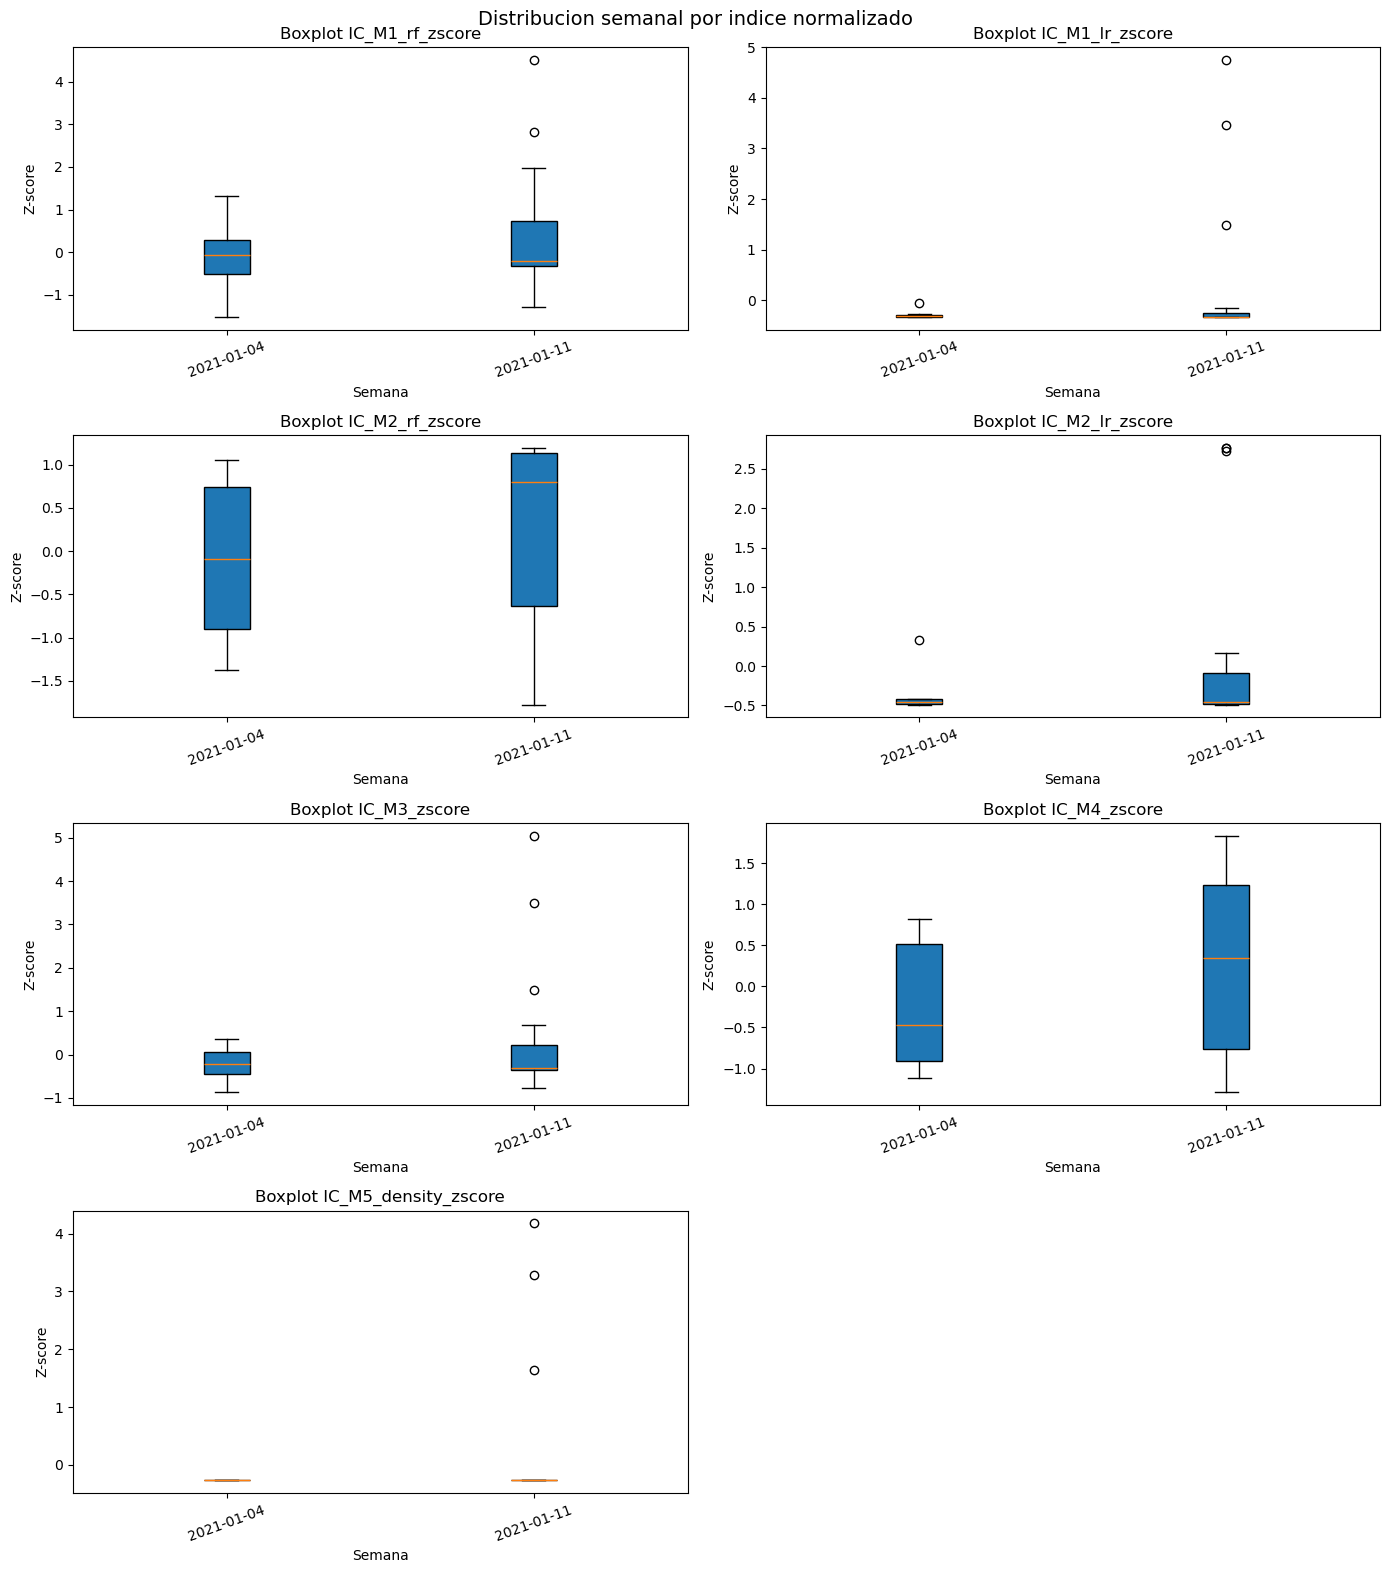

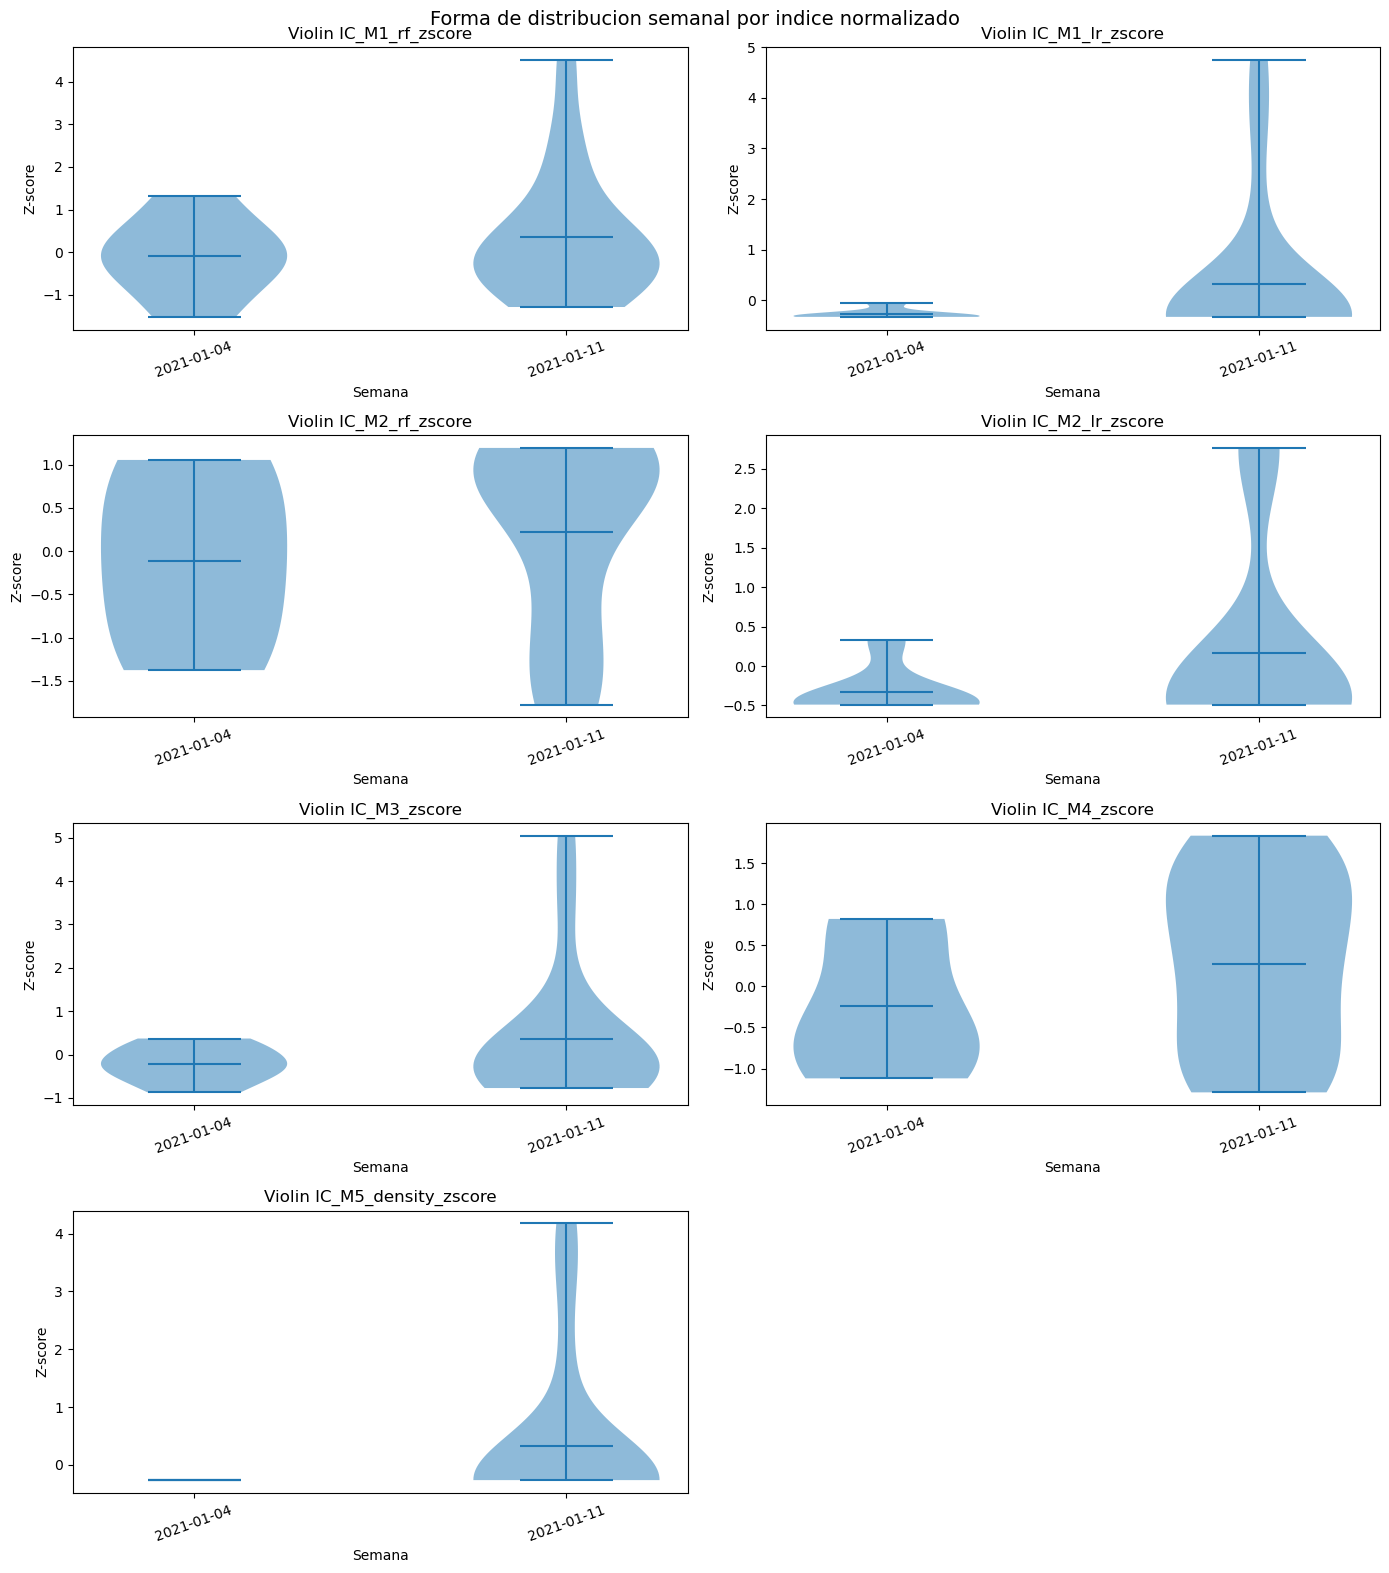

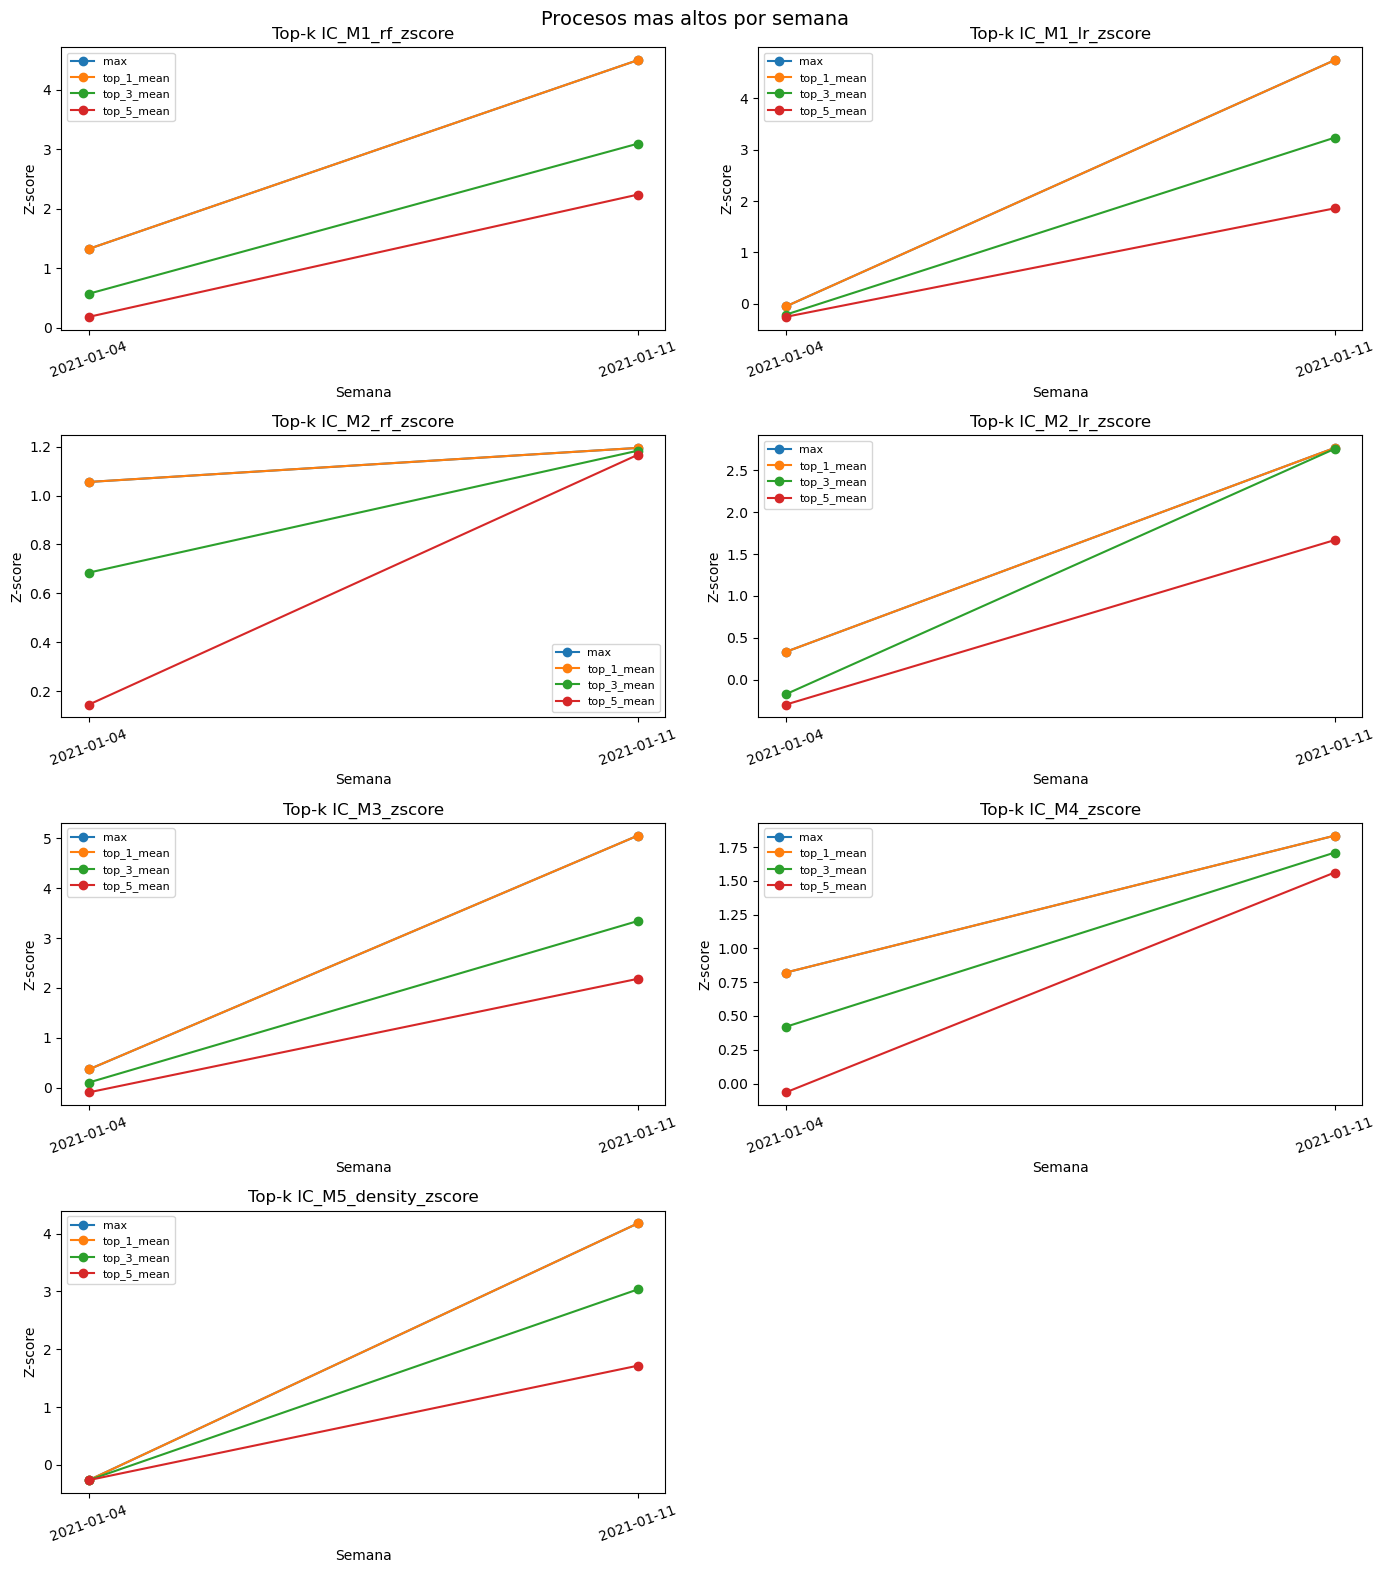

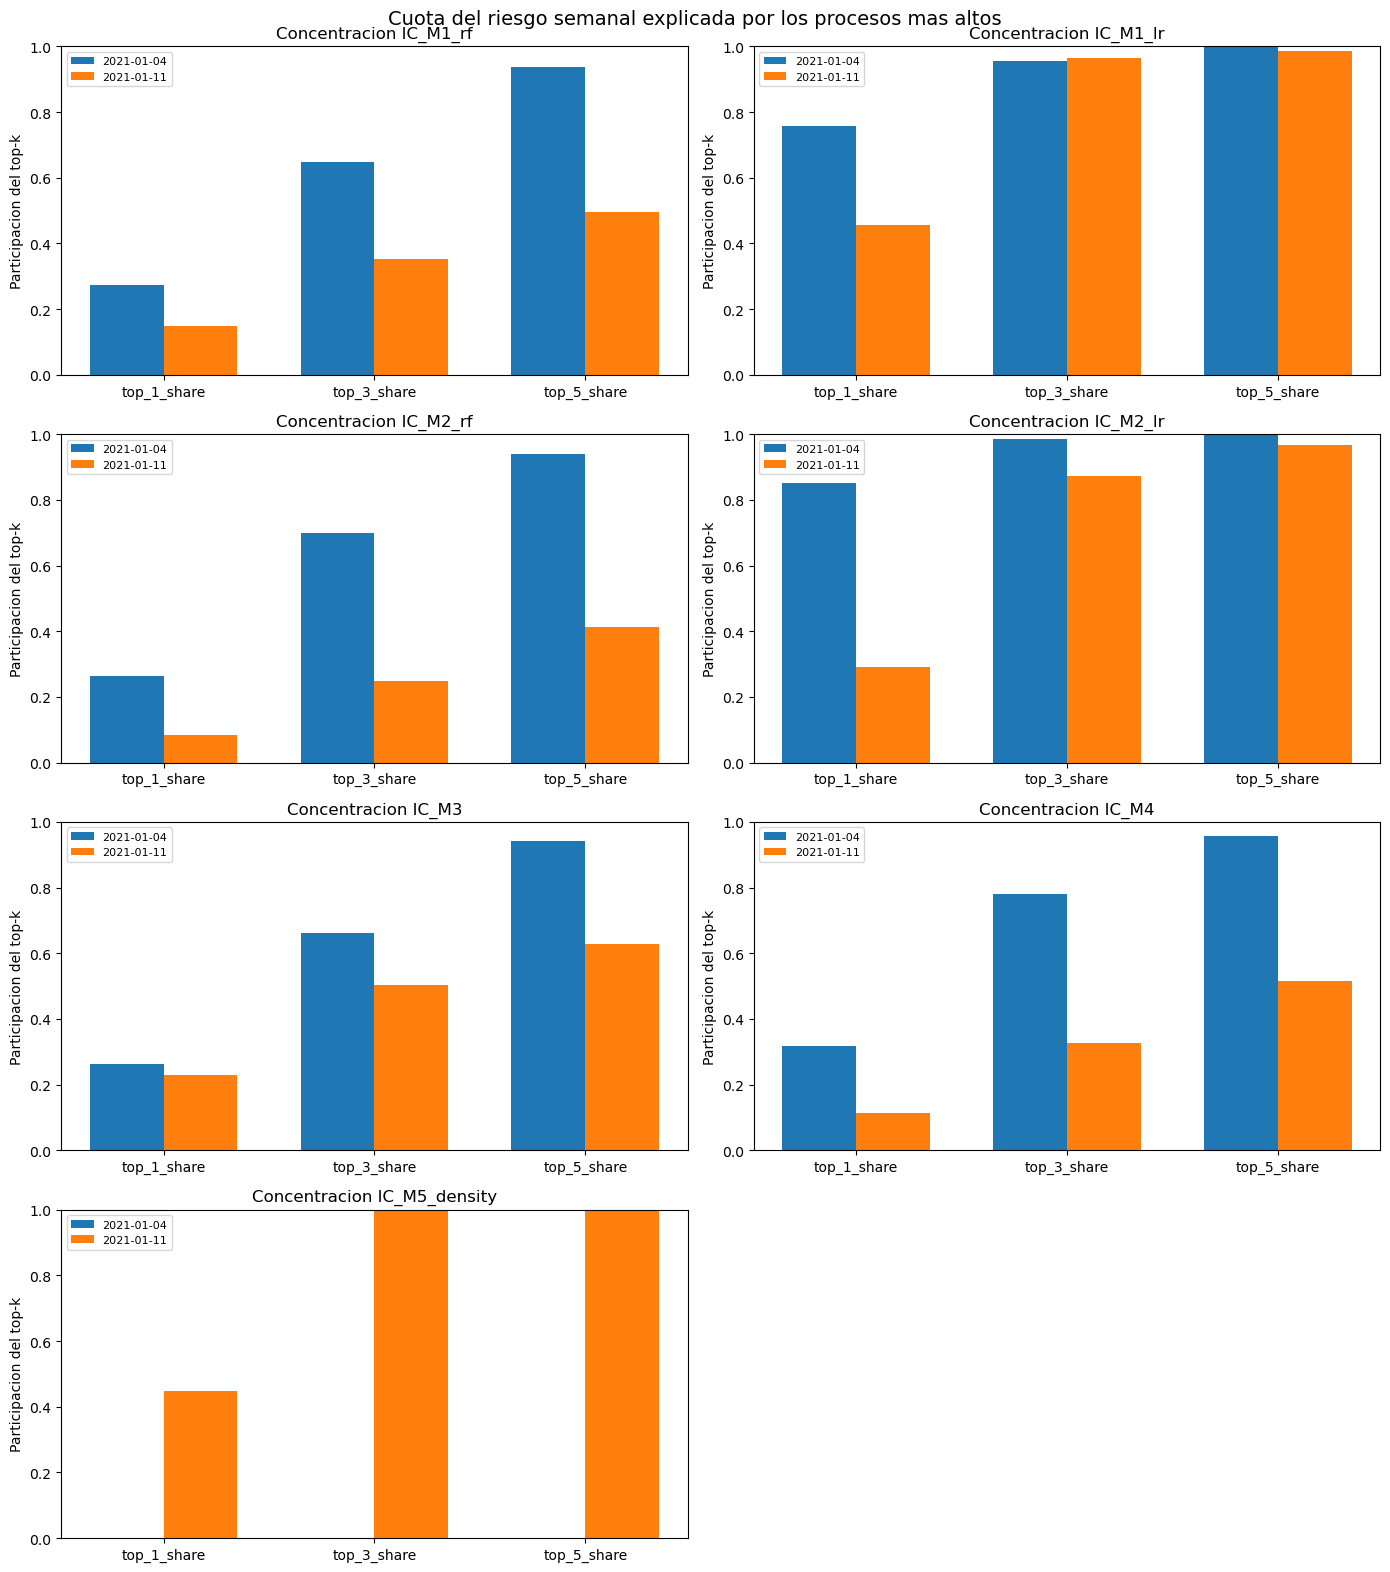

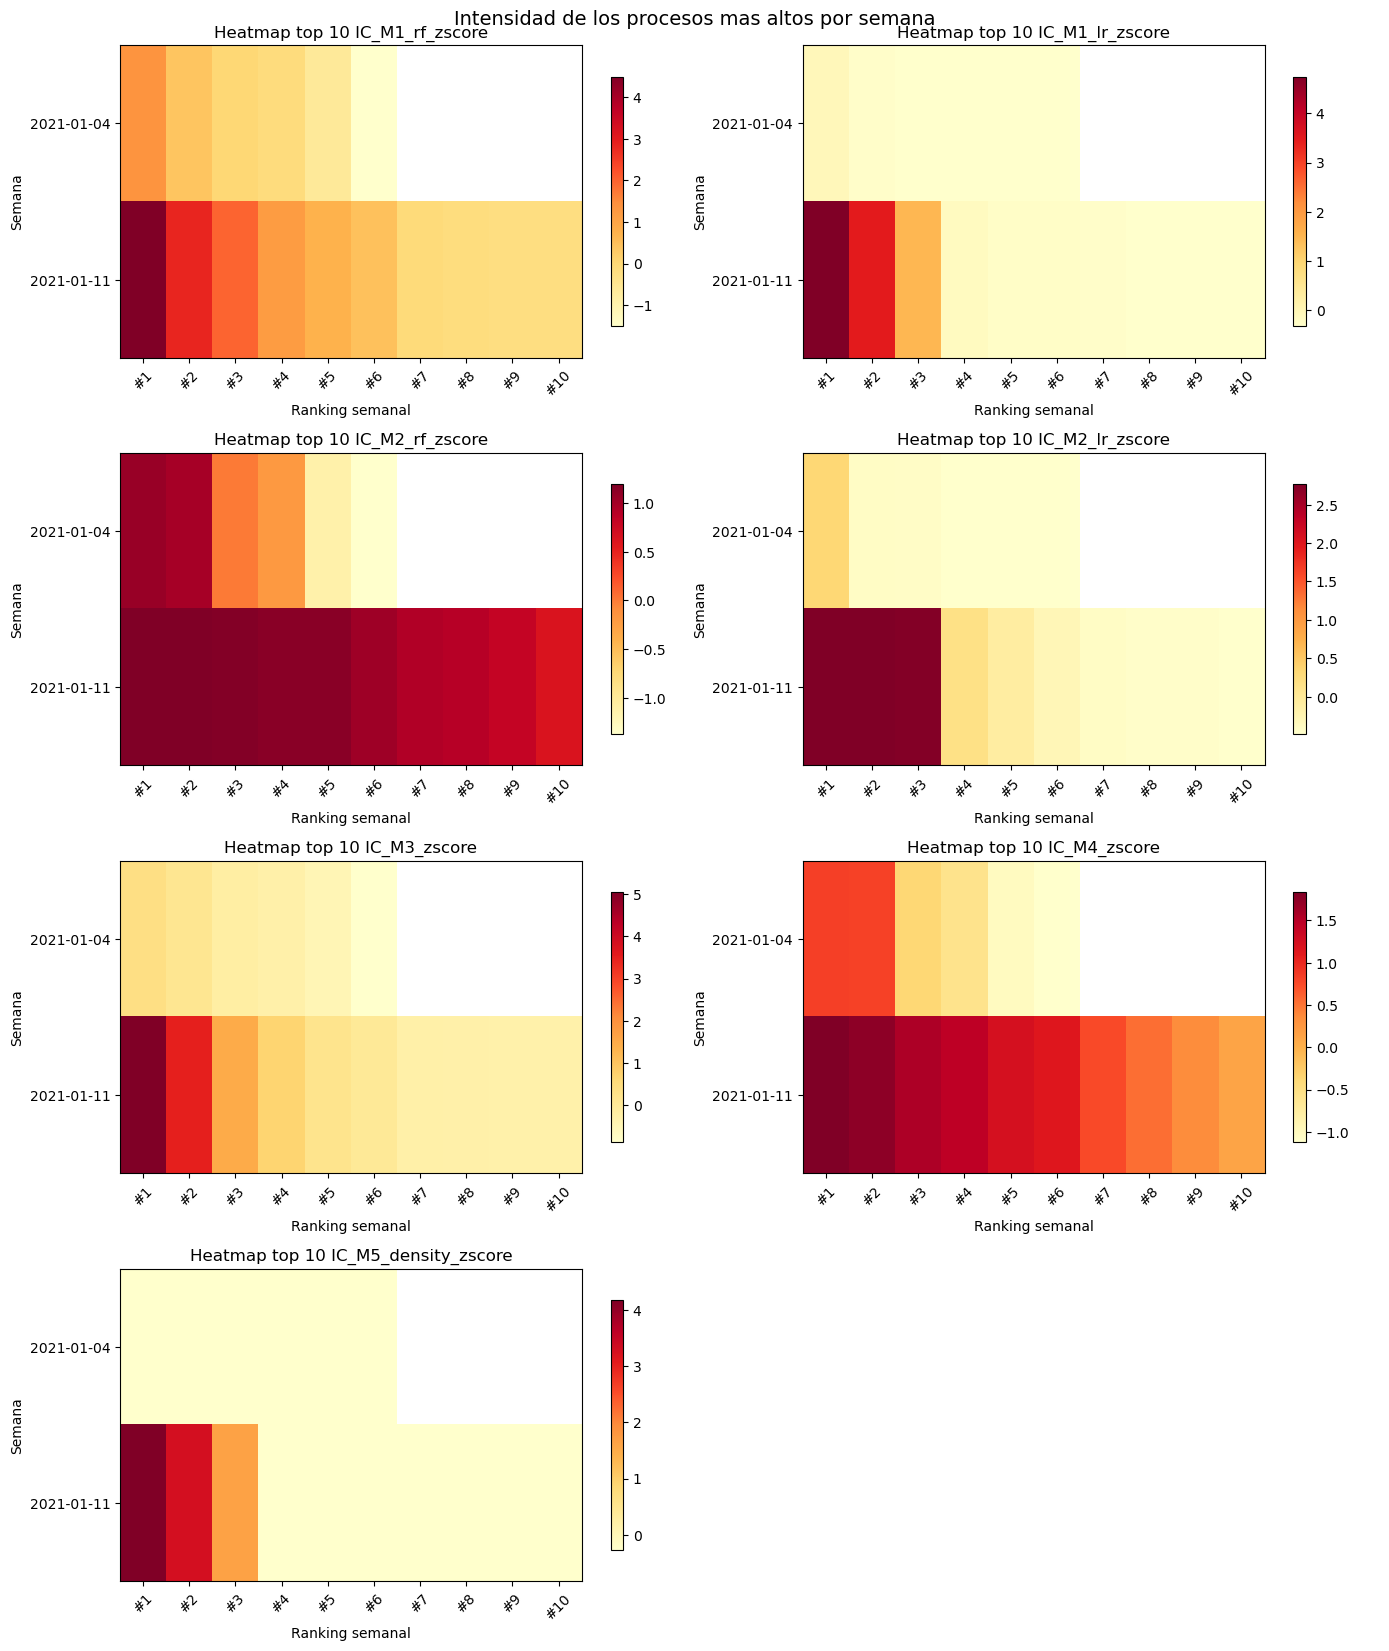

In [13]:
print(f"Semanas seleccionadas: {selected_weeks}")
print(weekly_process_df.groupby("week_label")["contract_id"].nunique().rename("n_procesos"))

plot_weekly_boxplots(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks)
plot_weekly_violins(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks)

topk_summary_df = compute_topk_summary(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, TOP_K_VALUES)
plot_topk_lines(topk_summary_df, ZSCORE_INDEX_COLUMNS)

concentration_summary_df = compute_concentration_summary(weekly_process_df, RAW_INDEX_COLUMNS, selected_weeks, TOP_K_VALUES)
plot_concentration_bars(concentration_summary_df, RAW_INDEX_COLUMNS)

plot_weekly_heatmaps(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, top_n=10)


## Barras por proceso

Esta seccion agrega graficos de barras por proceso para cada semana seleccionada. Se muestran todos los procesos de la semana y se mantiene el mismo orden de `contract_id` en todos los indices de esa semana para facilitar la comparacion visual y ver si los puntajes altos se concentran en procesos particulares.


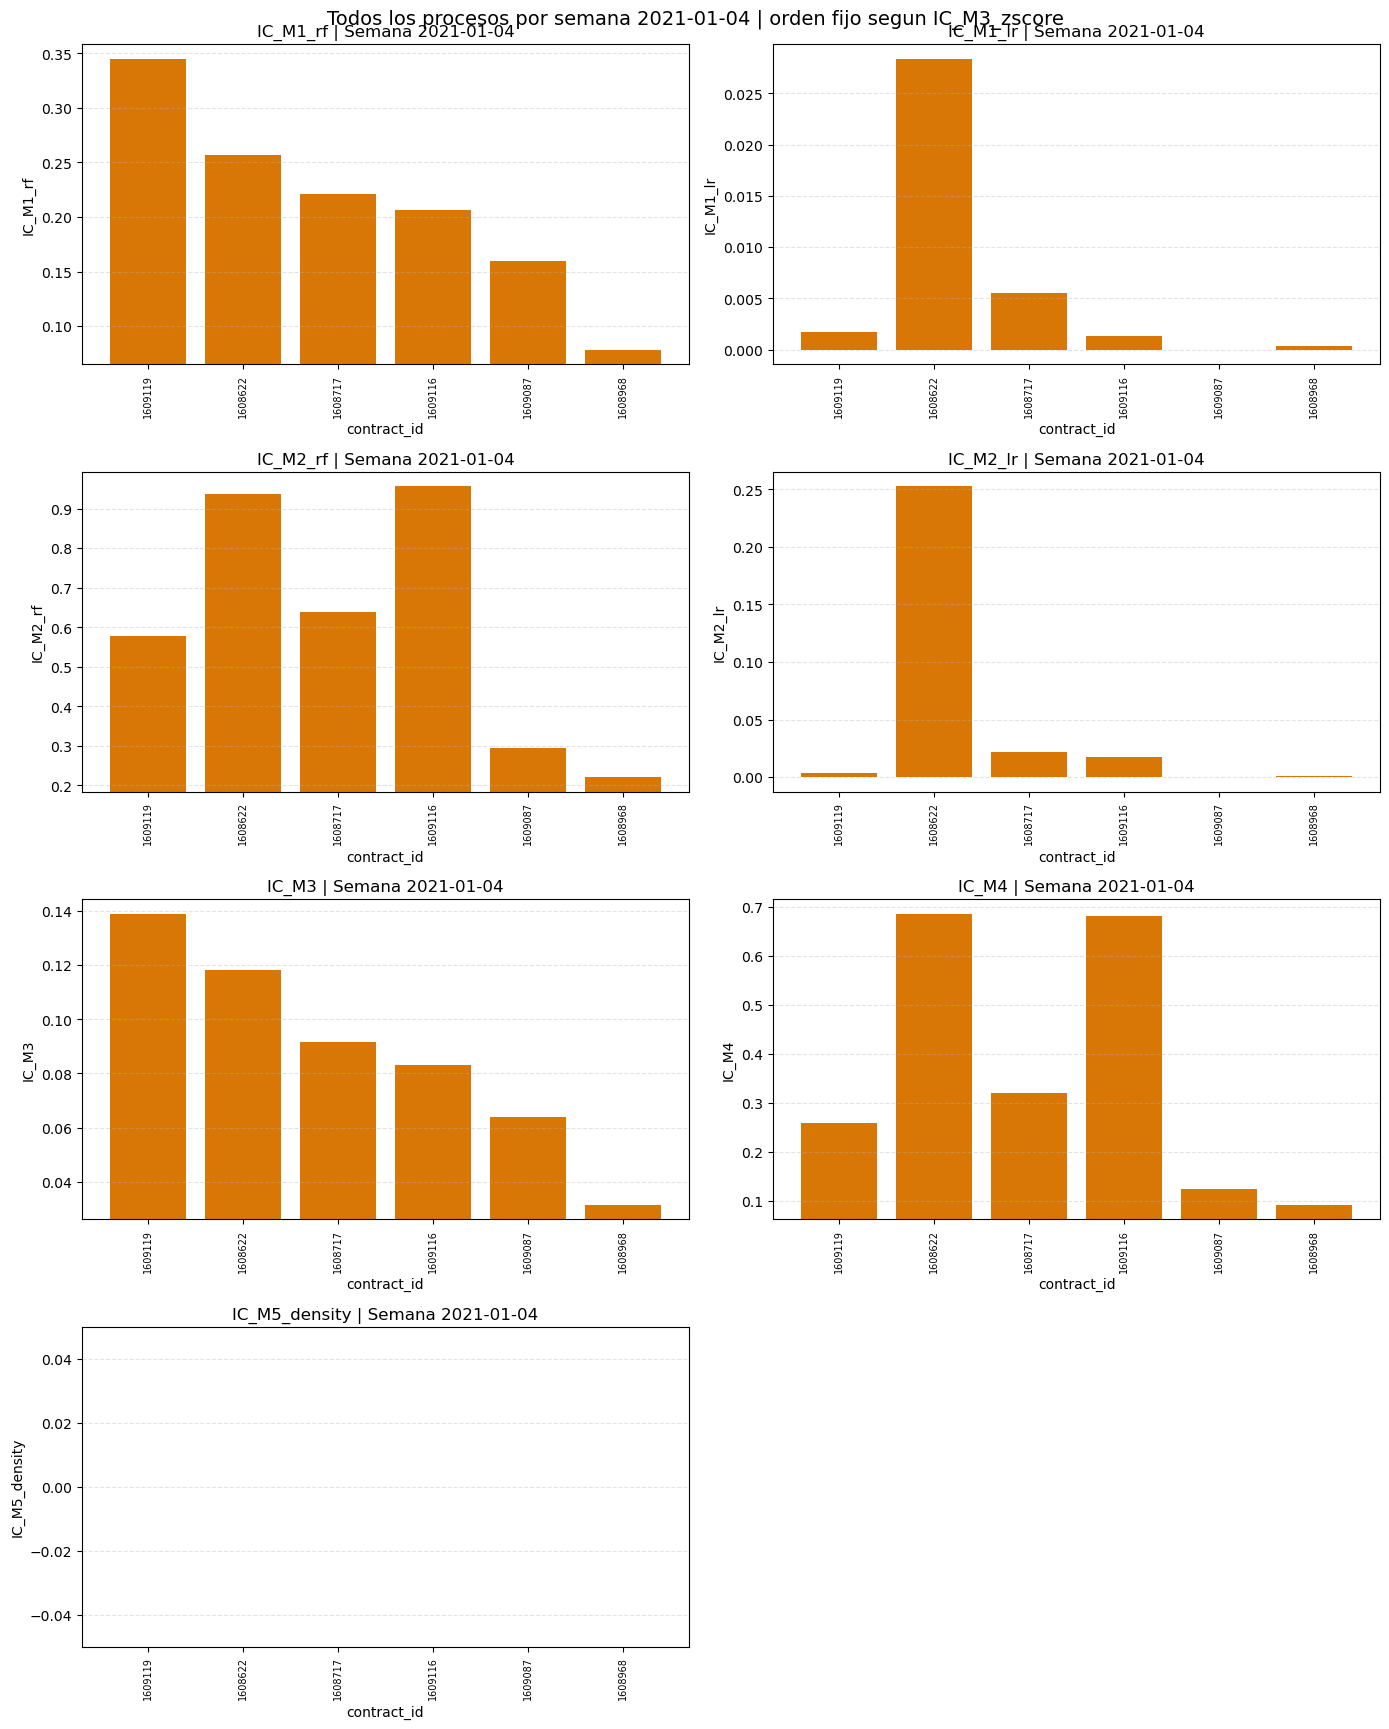

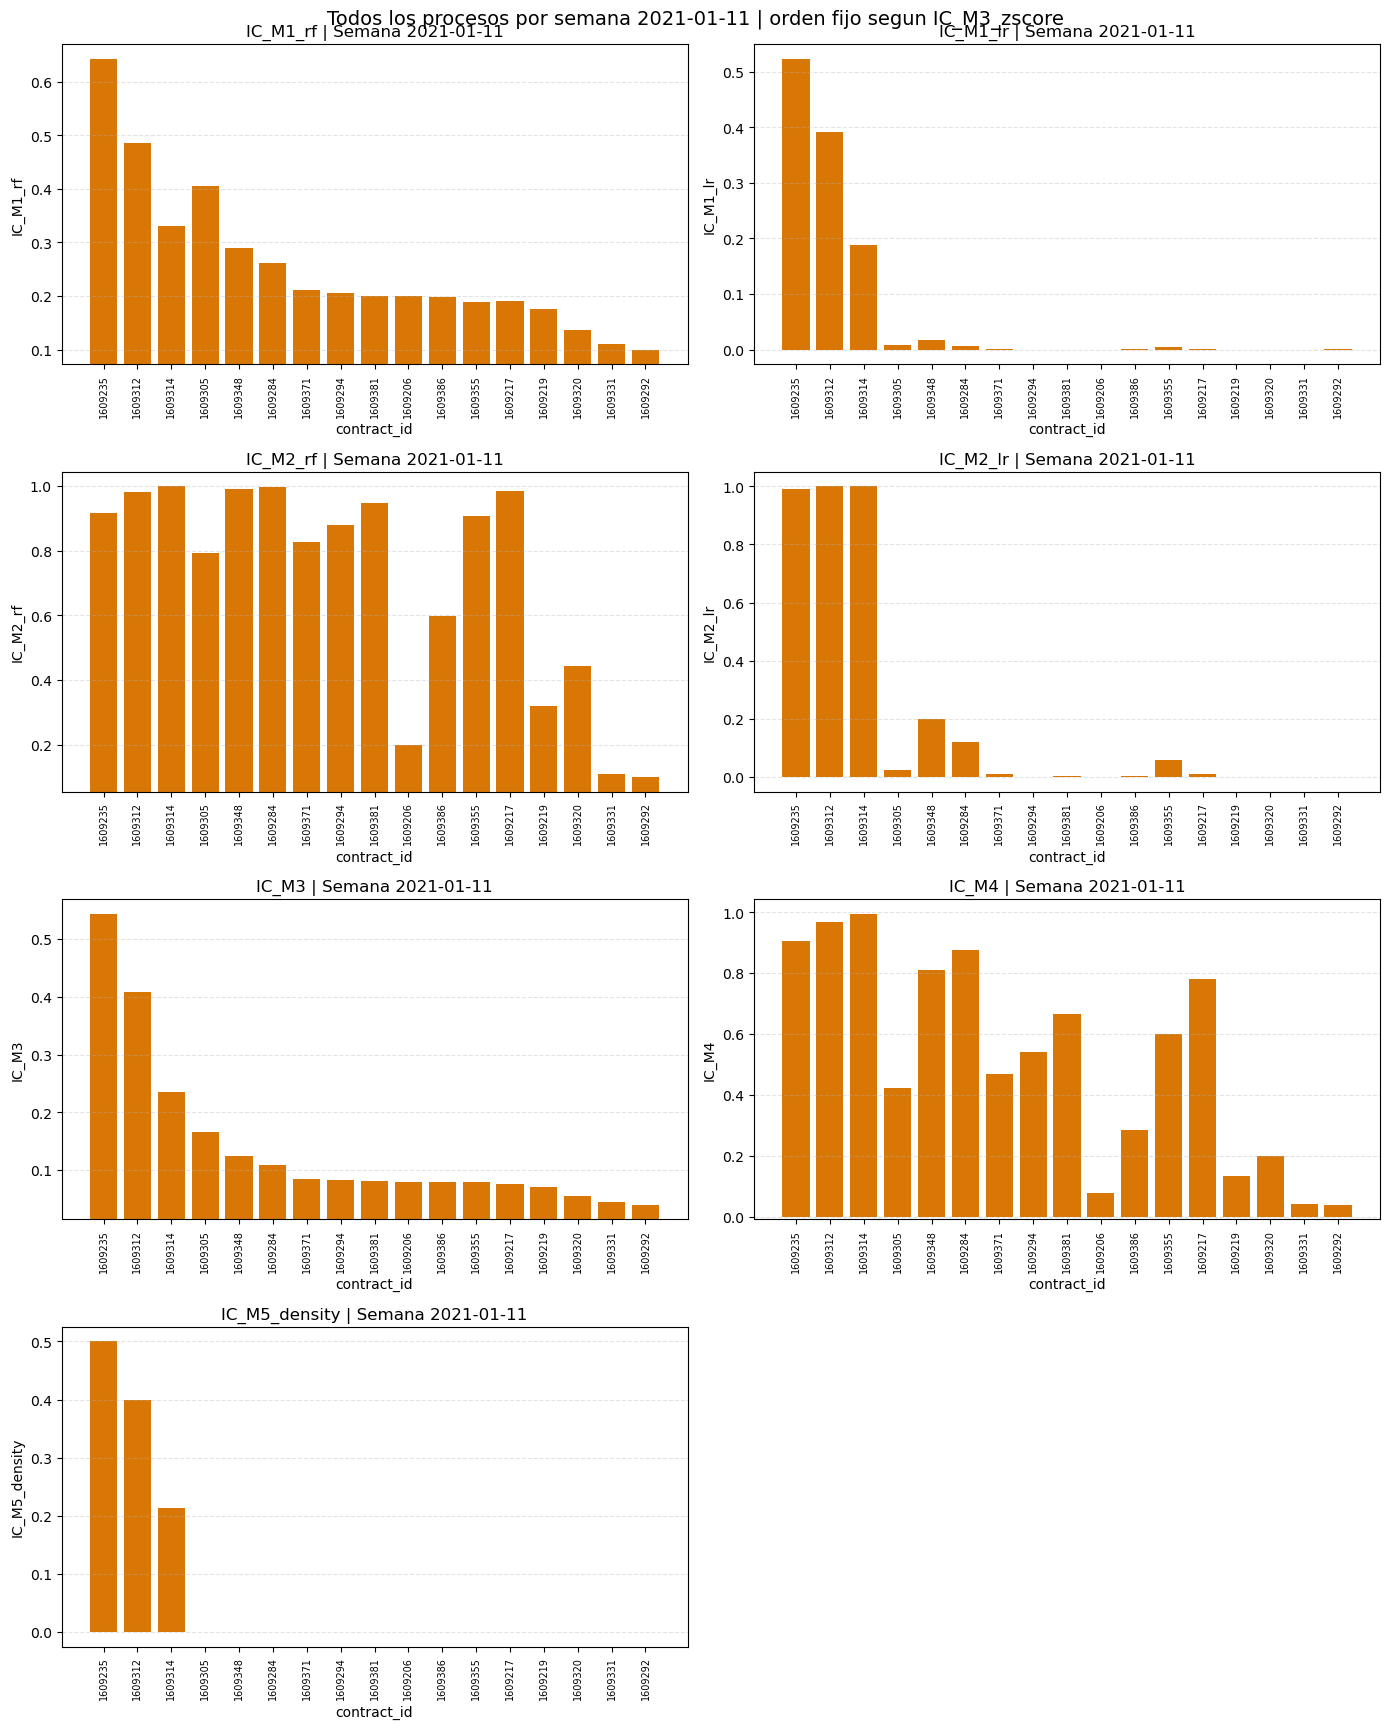

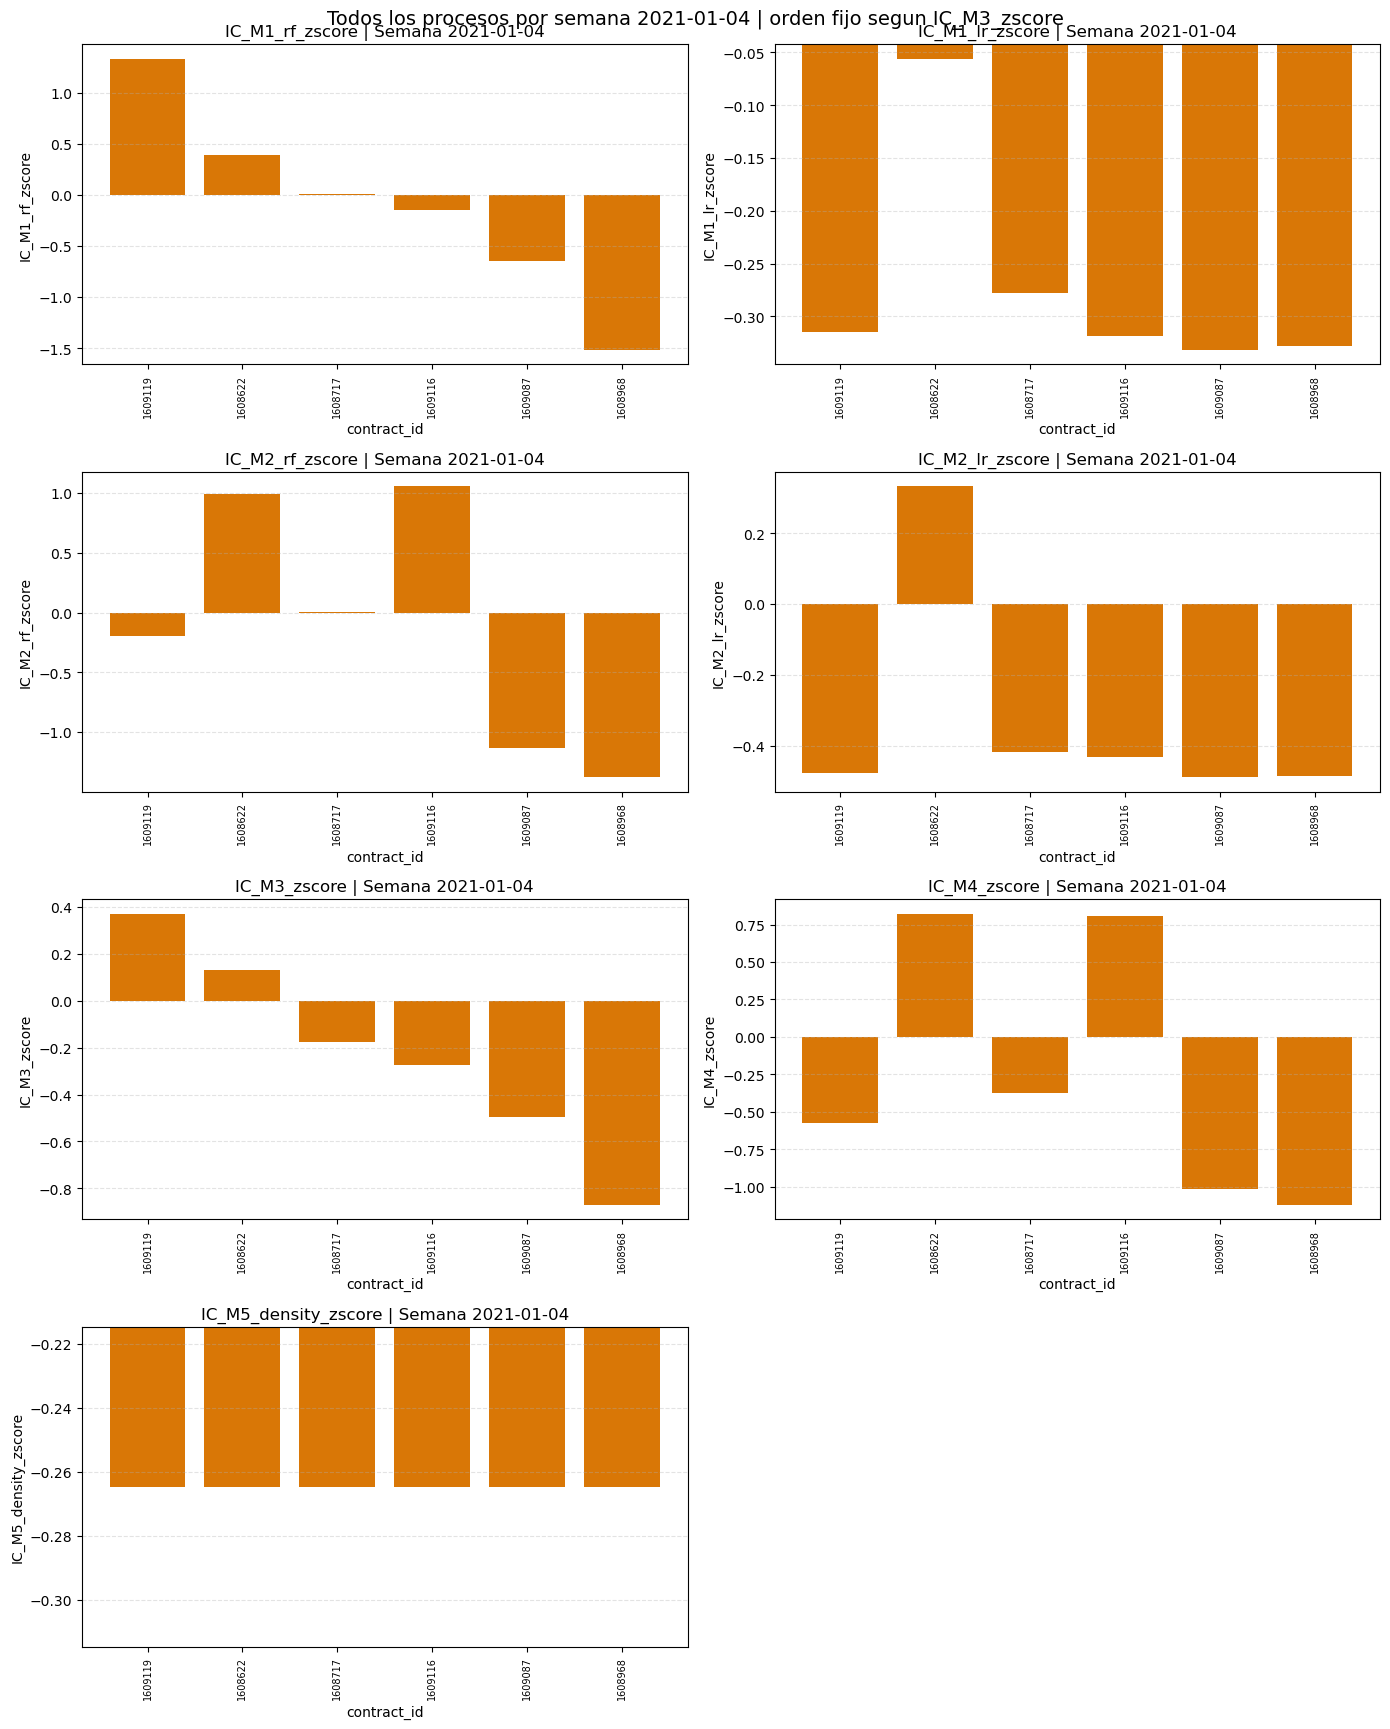

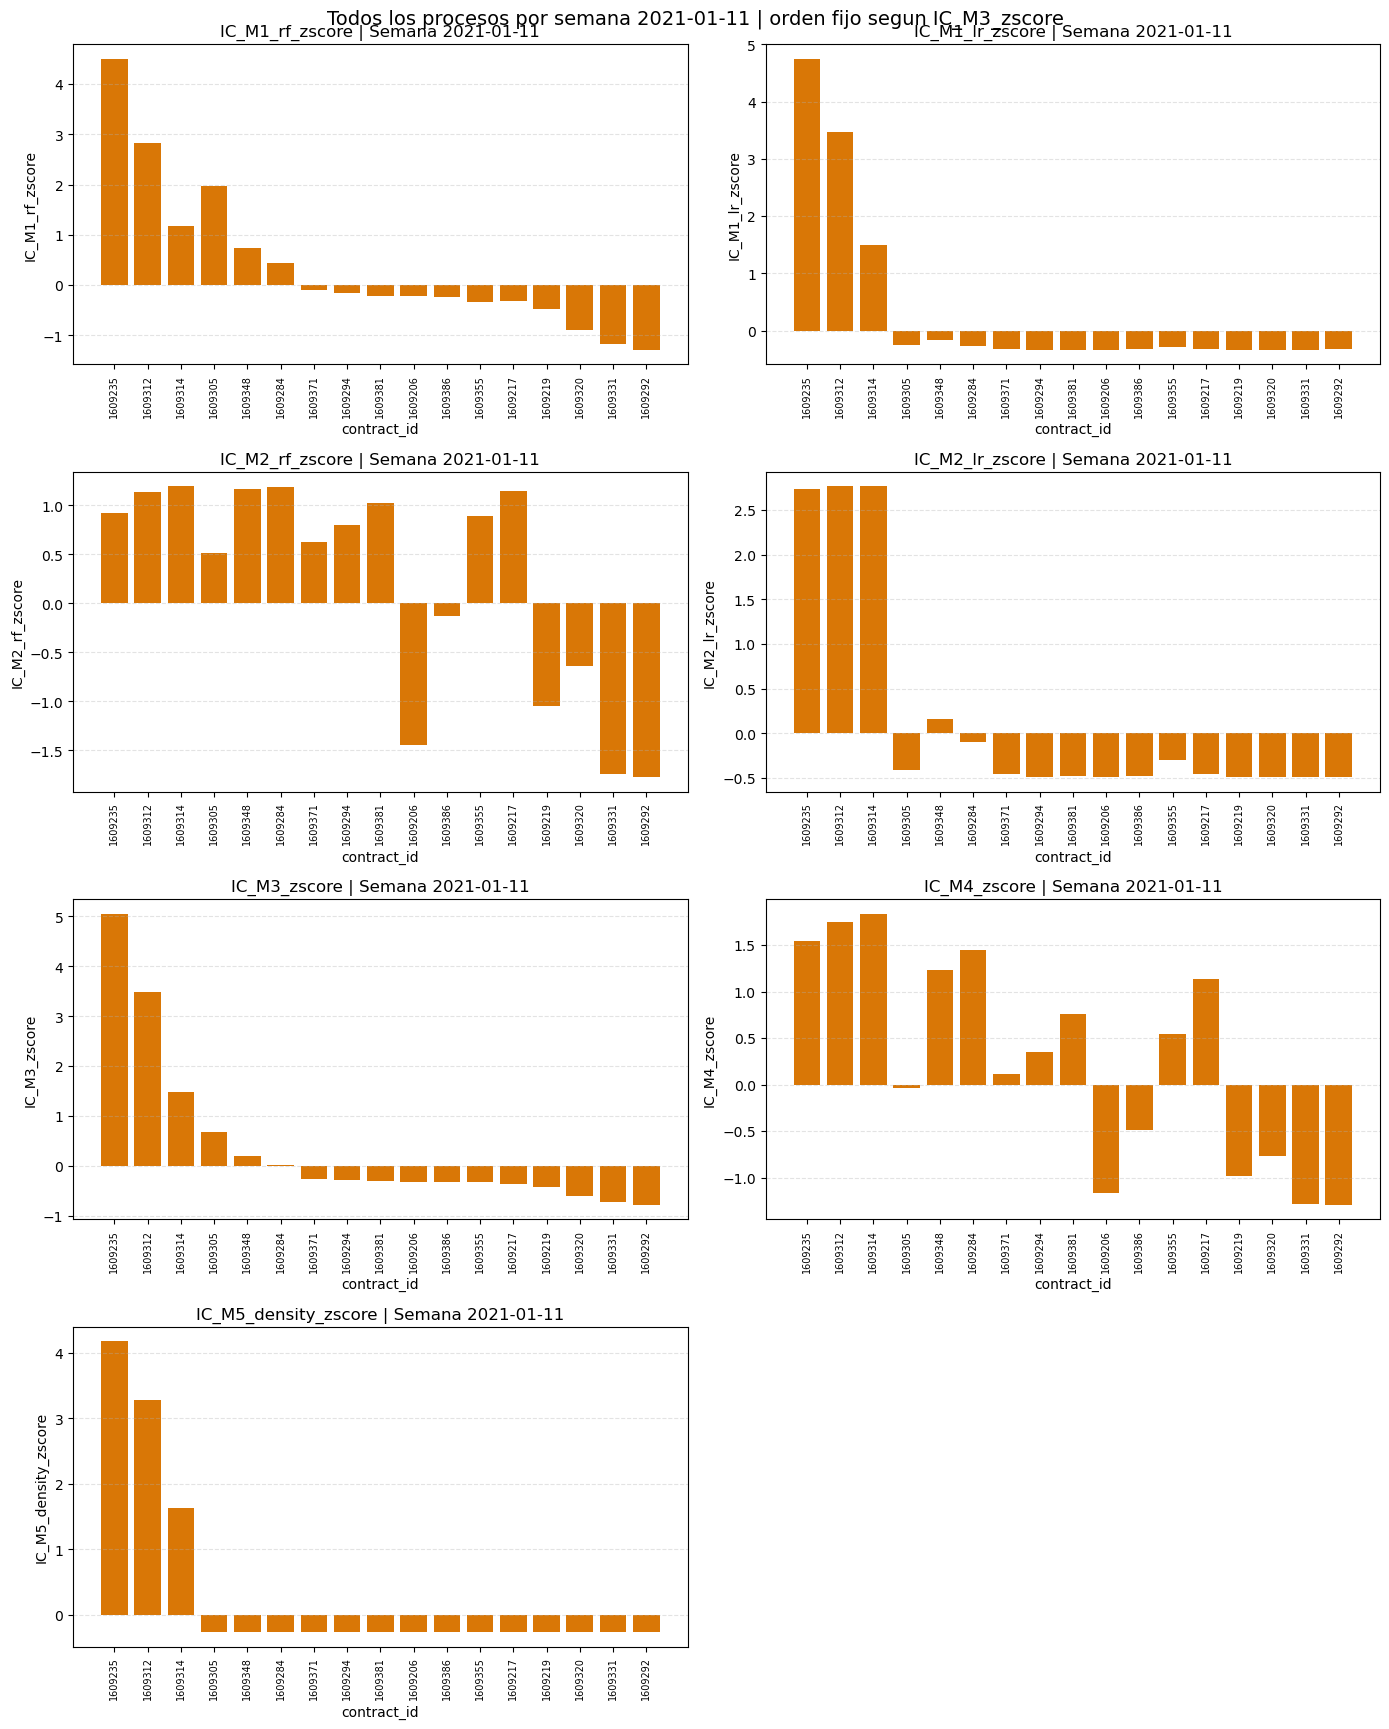

In [16]:
PROCESS_ORDER_INDEX = "IC_M3_zscore"

def plot_all_process_bars_by_week(
    df: pd.DataFrame,
    index_columns: list[str],
    selected_weeks: list[str],
    order_index: str,
) -> None:
    for week in selected_weeks:
        week_df = df[df["week_label"] == week].copy()
        week_df = week_df.sort_values(order_index, ascending=False).reset_index(drop=True)
        process_positions = np.arange(len(week_df))
        process_labels = week_df["contract_id"].astype(str).tolist()
        fig, axes = make_axis_grid(len(index_columns), ncols=2, figsize_scale=4.4)
        for ax, col in zip(axes, index_columns):
            values = week_df[col].to_numpy()
            ax.bar(process_positions, values, color="#d97706")
            ax.set_title(f"{col} | Semana {week}")
            ax.set_xlabel("contract_id")
            ax.set_ylabel(col)
            ax.set_xticks(process_positions)
            ax.set_xticklabels(process_labels, rotation=90, fontsize=7)
            value_min = float(np.min(values))
            value_max = float(np.max(values))
            value_range = value_max - value_min
            padding = 0.05 * value_range if value_range > 0 else max(abs(value_max) * 0.05, 0.05)
            ax.set_ylim(value_min - padding, value_max + padding)
            ax.grid(axis="y", linestyle="--", alpha=0.35)
        fig.suptitle(f"Todos los procesos por semana {week} | orden fijo segun {order_index}", fontsize=14)
        fig.tight_layout()
        plt.show()


plot_all_process_bars_by_week(weekly_process_df, RAW_INDEX_COLUMNS, selected_weeks, order_index=PROCESS_ORDER_INDEX)
plot_all_process_bars_by_week(weekly_process_df, ZSCORE_INDEX_COLUMNS, selected_weeks, order_index=PROCESS_ORDER_INDEX)
